# Employee Attrition Risk Prediction

**Objective:** Estimate voluntary attrition risk for workforce planning without treating predictions as employment decisions.

This notebook uses a deterministic, domain-shaped demo dataset so the end-to-end classification workflow is executable without private data. Reported metrics describe this demo only.


## 1. Setup and reproducibility


In [1]:
import platform
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
sns.set_theme(style="whitegrid", palette="deep")

print(f"Python: {platform.python_version()}")
print(f"pandas: {pd.__version__} | NumPy: {np.__version__} | scikit-learn: {sklearn.__version__}")
print(f"Random seed: {RANDOM_STATE}")


Python: 3.12.13
pandas: 2.2.3 | NumPy: 2.3.5 | scikit-learn: 1.8.0
Random seed: 42


## 2. Data contract and deterministic demo data


In [2]:
NUMERIC_FEATURES = ["monthly_income", "years_at_company", "overtime_hours", "job_satisfaction", "commute_km", "training_hours"]
CATEGORICAL_VALUES = {
  "department": [
    "engineering",
    "sales",
    "operations",
    "finance"
  ],
  "work_mode": [
    "office",
    "hybrid",
    "remote"
  ]
}
CATEGORICAL_FEATURES = list(CATEGORICAL_VALUES)
TARGET = "attrition"
N_ROWS = 1400

data = pd.DataFrame()
for i, name in enumerate(NUMERIC_FEATURES):
    center = 25 + 18 * i
    spread = 6 + 3 * i
    values = rng.normal(center, spread, N_ROWS)
    data[name] = np.maximum(values, 0).round(3)
for name, values in CATEGORICAL_VALUES.items():
    data[name] = rng.choice(values, size=N_ROWS)

numeric_signal = sum((i + 1) * (data[name] - data[name].mean()) / (data[name].std() + 1e-9) for i, name in enumerate(NUMERIC_FEATURES))
category_signal = sum(data[name].astype("category").cat.codes * (0.25 + 0.10 * i) for i, name in enumerate(CATEGORICAL_FEATURES))
latent = numeric_signal + category_signal + rng.normal(0, 2.2, len(data))
data["attrition"] = np.where(latent > np.quantile(latent, 0.60), "yes", "no")


for column in NUMERIC_FEATURES[:2]:
    missing_rows = rng.choice(data.index, size=18, replace=False)
    data.loc[missing_rows, column] = np.nan

print(f"Dataset shape: {data.shape[0]:,} rows × {data.shape[1]} columns")
display(data.head())


Dataset shape: 1,400 rows × 9 columns


,monthly_income,years_at_company,overtime_hours,job_satisfaction,commute_km,training_hours,department,work_mode,attrition
0,26.828,53.643,57.885,66.864,127.417,84.325,operations,remote,no
1,18.760,40.084,72.638,49.162,121.159,96.297,sales,hybrid,no
2,29.503,41.163,71.491,87.109,108.391,99.897,finance,hybrid,no
3,30.643,38.575,49.217,110.801,103.812,110.636,engineering,remote,yes
4,13.294,37.774,50.734,99.843,95.417,99.018,engineering,hybrid,no


## 3. Data quality and exploratory analysis


,dtype,missing,missing_pct,unique
monthly_income,float64,18,1.29,1335
years_at_company,float64,18,1.29,1352
overtime_hours,float64,0,0.00,1373
job_satisfaction,float64,0,0.00,1381
commute_km,float64,0,0.00,1390
training_hours,float64,0,0.00,1384
department,object,0,0.00,4
work_mode,object,0,0.00,3
attrition,object,0,0.00,2


,count,mean,std,min,25%,50%,75%,max
monthly_income,1382.0,24.867,5.970,3.110,20.918,25.037,28.700,44.073
years_at_company,1382.0,42.683,9.113,15.426,36.714,42.930,48.737,69.228
overtime_hours,1400.0,61.092,11.844,28.007,52.846,61.051,68.899,102.449
job_satisfaction,1400.0,78.869,14.860,31.845,68.610,79.053,88.414,128.065
commute_km,1400.0,97.663,18.811,17.996,85.883,96.800,110.415,154.747
training_hours,1400.0,114.543,20.528,51.656,100.929,114.073,127.970,199.542


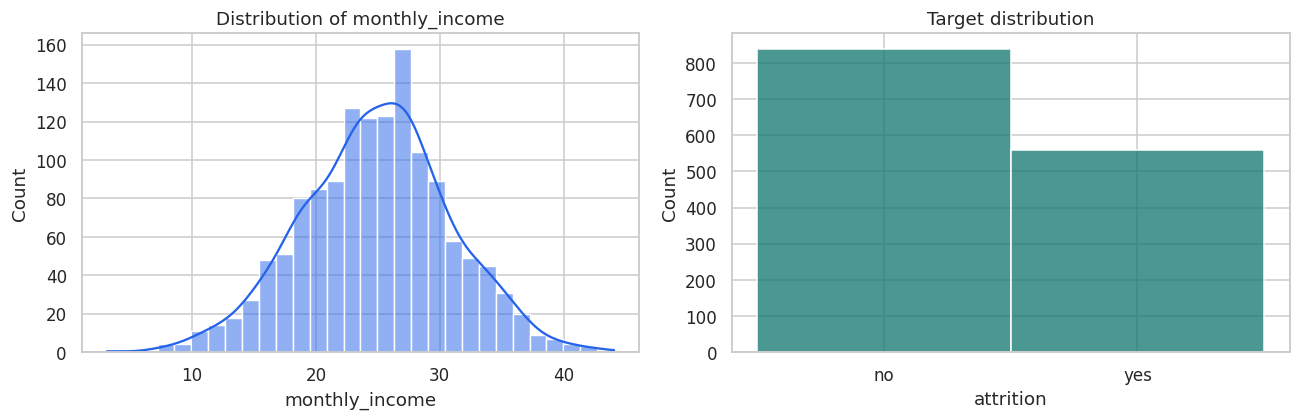

In [3]:
overview = pd.DataFrame({
    "dtype": data.dtypes.astype(str),
    "missing": data.isna().sum(),
    "missing_pct": (100 * data.isna().mean()).round(2),
    "unique": data.nunique(dropna=False),
})
display(overview)
display(data[NUMERIC_FEATURES + [TARGET]].describe().T.round(3))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=data, x=NUMERIC_FEATURES[0], kde=True, ax=axes[0], color="#2563eb")
sns.histplot(data=data, x=TARGET, ax=axes[1], color="#0f766e")
axes[0].set_title(f"Distribution of {NUMERIC_FEATURES[0]}")
axes[1].set_title("Target distribution")
plt.tight_layout()
plt.show()


## 4. Leakage-safe preprocessing, baseline, and model comparison


In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

X = data[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = data[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y)

numeric_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
categorical_pipe = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])
preprocessor = ColumnTransformer([("numeric", numeric_pipe, NUMERIC_FEATURES), ("categorical", categorical_pipe, CATEGORICAL_FEATURES)])
models = {
    "Majority baseline": DummyClassifier(strategy="prior"),
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=180, min_samples_leaf=3, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=1),
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
comparison = []
for name, estimator in models.items():
    candidate = Pipeline([("preprocessor", preprocessor), ("model", estimator)])
    scores = cross_validate(candidate, X_train, y_train, cv=cv, scoring="f1_macro", n_jobs=1)
    comparison.append({"model": name, "cv_macro_f1": scores["test_score"].mean(), "cv_std": scores["test_score"].std()})
comparison = pd.DataFrame(comparison).sort_values("cv_macro_f1", ascending=False).reset_index(drop=True)
display(comparison.round(4))


,model,cv_macro_f1,cv_std
0,Logistic Regression,0.9162,0.0228
1,Random Forest,0.8824,0.0220
2,Majority baseline,0.3750,0.0000


## 5. Holdout evaluation


Selected model: Logistic Regression
Holdout accuracy: 0.9400
Holdout macro F1: 0.9379
Holdout ROC AUC: 0.9820


,precision,recall,f1-score,support
no,0.9610,0.9381,0.9494,210.00
yes,0.9103,0.9429,0.9263,140.00
accuracy,0.9400,0.9400,0.9400,0.94
macro avg,0.9357,0.9405,0.9379,350.00
weighted avg,0.9407,0.9400,0.9402,350.00


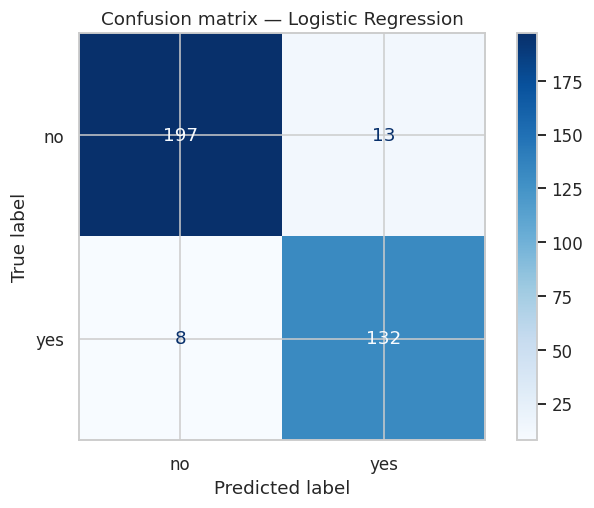

In [5]:
best_name = comparison.iloc[0]["model"]
best_pipeline = Pipeline([("preprocessor", preprocessor), ("model", models[best_name])]).fit(X_train, y_train)
predictions = best_pipeline.predict(X_test)
probabilities = best_pipeline.predict_proba(X_test)[:, list(best_pipeline.classes_).index("yes")]
print(f"Selected model: {best_name}")
print(f"Holdout accuracy: {accuracy_score(y_test, predictions):.4f}")
print(f"Holdout macro F1: {f1_score(y_test, predictions, average='macro'):.4f}")
print(f"Holdout ROC AUC: {roc_auc_score((y_test == 'yes').astype(int), probabilities):.4f}")
display(pd.DataFrame(classification_report(y_test, predictions, output_dict=True, zero_division=0)).T.round(4))
ConfusionMatrixDisplay.from_predictions(y_test, predictions, cmap="Blues")
plt.title(f"Confusion matrix — {best_name}")
plt.tight_layout()
plt.show()


## 6. Permutation importance and diagnostics


,feature,importance_mean,importance_std
5,training_hours,0.2194,0.0111
4,commute_km,0.1977,0.0170
3,job_satisfaction,0.1731,0.0317
2,overtime_hours,0.1137,0.0113
1,years_at_company,0.0594,0.0064
0,monthly_income,0.0331,0.0069
7,work_mode,0.0206,0.0073
6,department,0.0120,0.0049


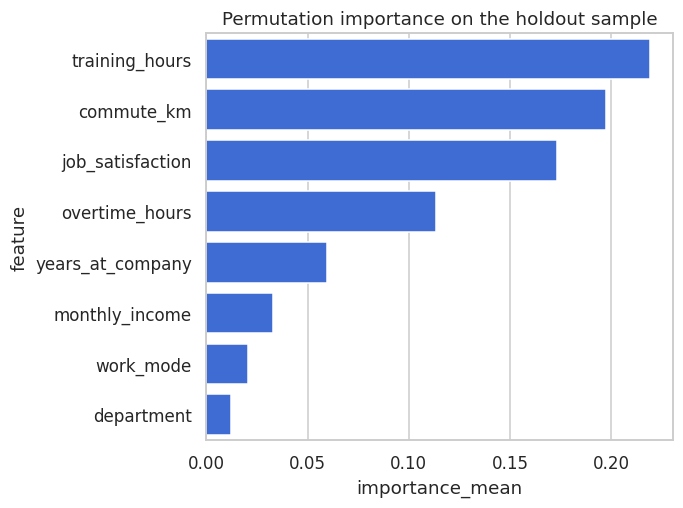

In [6]:
from sklearn.inspection import permutation_importance

sample_size = min(500, len(X_test))
X_explain = X_test.sample(sample_size, random_state=RANDOM_STATE)
y_explain = y_test.loc[X_explain.index]
importance = permutation_importance(best_pipeline, X_explain, y_explain, n_repeats=5, random_state=RANDOM_STATE, n_jobs=1)
importance_df = pd.DataFrame({
    "feature": X_explain.columns,
    "importance_mean": importance.importances_mean,
    "importance_std": importance.importances_std,
}).sort_values("importance_mean", ascending=False)
display(importance_df.round(4))
sns.barplot(data=importance_df, x="importance_mean", y="feature", color="#2563eb")
plt.title("Permutation importance on the holdout sample")
plt.tight_layout()
plt.show()


## 7. Limitations and next steps

- Replace demo data with licensed, representative, versioned production data.
- Review target definition, leakage risks, subgroup behavior, calibration, and domain error costs.
- Add uncertainty estimates, drift monitoring, human-review policies, and retraining criteria before deployment.
- Treat feature importance as model behavior—not causality.
